# Predicting Failed Food Businesses: Final Model and Contact List

**IAT 461, Summer 2026: Final delivery, August 11**
Student (data scientist): Mahdi Taziki (301373483)
Client: Jason Salonga (301400669), Greater Vancouver Food Bank

## 1. The problem and method choice

The client wants the Greater Vancouver Food Bank to identify food businesses that
may need support before they close. The requested output is a ranked list that the
Community Food Access Coordinator can use to decide who to contact first.

The proposal asks three questions:

1. Is there a pattern in the licence data that shows which food businesses fail?
2. Which early signs matter most, business type or staff count?
3. Can we rank businesses so the food bank helps the most at risk first?

Section 12 answers each of these against the success criteria in the proposal.

### Why I used supervised classification

The `status` column provides a labelled outcome for every record, and the client
specified which statuses should be treated as failures. I therefore used binary
classification to learn the relationship between the available licence details
and the failure label.

Clustering could group similar businesses, but it would not use the known status
outcome and would not directly answer who should be contacted first. It could be
useful for a separate question about business or neighbourhood groups, but not for
the ranking requested here.

There is an important limit to this setup. The file is a single snapshot, so the
label describes current licence status rather than a later outcome measured after
the predictors. The analysis can evaluate a status-based ranking, but it cannot
validate a forecast of which currently issued businesses will fail in the future.

### Work completed since the August 9 draft

[`02_Modeling.ipynb`](02_Modeling.ipynb) compared logistic regression with a
random forest. This notebook adds label sensitivity, nested tuning, repeated
precision-at-k evaluation, calibration, a held-out check, the final CSV, and the
client summary.

In an August 9 follow-up, the client confirmed that `Pending` and `Inactive`
should count as failures because he considers both to be cases where the business
became unresponsive. I use the broader label Jason confirmed and test three
stricter definitions in Section 5. The client decision settles the project label,
but it does not prove that those statuses represent future business failures.

The client also said the coordinator should contact around 10 businesses per week.
I use 10 for the contact schedule and evaluate k = 10 in Section 7.

I also corrected a mistake from the draft. The 63 percent baseline in the Phase 2
agreement belongs to the separate Aquila project described in Section 4 of that
document, so it is not a baseline for this analysis.

## 2. Data

The working file is `vancouver_food_businesses_sample.csv`. It contains 221 food
businesses and 12 columns filtered by the client from the City of Vancouver
Business Licences open
dataset. `make_foodbank_dataset.py` in the repository root is the script that
produced it.

### EDA summary

The original file has 221 rows and 12 columns. Before deduplication, the narrow
label marks 20 records and the broader label marks 53. Keeping the latest
record for each licence leaves 219 rows and 51 broad-label positives.

Business type has the clearest observed relationship with the broad label. The
failure-status rate ranges from 4.8 percent for food wholesalers to 43.5 percent
for food retailers, although the category sizes are small. Neighbourhood rates
also vary, but several areas have few records. Employee count is
right-skewed cause the overall median is 5 and the maximum is 1,955. Failed records have
a median of 5 employees and other records have a median of 6, so employee count
does not separate the groups clearly.

![Failure label distributions](../figures/02_target_distribution.png)

![Failure status by business type](../figures/03_businesstype.png)

![Employee count distribution](../figures/05_employees.png)

The complete exploratory analysis, including missingness and neighbourhood
relationships, is in [`01_EDA.ipynb`](01_EDA.ipynb).

### Column dictionary

| column | type | used? | notes |
|---|---|---|---|
| `licencenumber` | ID | key only | licence identifier, also the deduplication key |
| `businessname` | nominal | output only | appears in the contact list so rows can be matched back |
| `businesstype` | nominal | **predictor** | restaurant, wholesale, retail, and so on |
| `localarea` | nominal | **predictor** | Vancouver neighbourhood, 20 values |
| `status` | nominal | label source | Issued, Pending, Cancelled, Inactive, Gone Out of Business |
| `failed` | binary | replaced | the client's original narrow label, rebuilt in the notebook |
| `numberofemployees` | quantitative | **predictor** | staff reported at licence time |
| `issueddate` | date | sort key only | dropped as a predictor, see below |
| `expireddate` | date | dropped | after the outcome, and constant where present |
| `feepaid` | quantitative | dropped | missing for about 53 percent of rows |
| `folderyear` | ordinal | dropped | 24 for 218 of 221 rows |
| `postalcode` | nominal | dropped | nearly unique, and overlaps `localarea` |

### Known data quality issues

These were all found in [`01_EDA.ipynb`](01_EDA.ipynb):

1. Missing values in `issueddate` and
   `expireddate` almost exactly identify `Pending` and `Cancelled` records. A flag
   for a missing `issueddate` predicts the wide label with about 98 percent
   accuracy. That is not a real signal, it is the record-keeping pattern, so both
   columns are dropped as predictors.
2. Two licence numbers appear twice with different
   statuses. Only the most recent record for each is kept, which takes 221 rows
   to 219.
3. `feepaid` is missing for about 53 percent of rows and is
   dropped. The three predictors have no missing values.
4. One business type has a single row, and 8 of 20
   neighbourhoods have fewer than 8 rows, so both are grouped.
5. `numberofemployees` runs from 0 to 1,955 with a median of 5.

## 3. Setup and cleaning

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.model_selection import (GridSearchCV, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_val_predict,
                                     cross_val_score, cross_validate,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder,
                                   StandardScaler)

SEED = 461
sns.set_theme(style="whitegrid", context="notebook")

PALETTE = {"survived": "#4C78A8", "failed": "#E45756"}
MODEL_COLOURS = {"Logistic regression": "#5B8FF9", "Random forest": "#9A6FB0"}
REFERENCE = "#767676"

CONTACTS_PER_WEEK = 10

In [2]:
raw = pd.read_csv("../vancouver_food_businesses_sample.csv")

NARROW_STATUSES = ["Cancelled", "Gone Out of Business"]
WIDE_STATUSES = NARROW_STATUSES + ["Pending", "Inactive"]
MIN_TYPE_N, MIN_AREA_N = 5, 8

CAT_FEATURES = ["businesstype_grouped", "localarea_grouped"]
NUM_FEATURES = ["numberofemployees"]
FEATURES = CAT_FEATURES + NUM_FEATURES


def prepare(frame):
    out = frame.copy()
    out["failed_narrow"] = out["status"].isin(NARROW_STATUSES).astype(int)
    out["failed_wide"] = out["status"].isin(WIDE_STATUSES).astype(int)

    out = (out.sort_values("issueddate")
              .drop_duplicates("licencenumber", keep="last")
              .reset_index(drop=True))

    type_counts = out["businesstype"].value_counts()
    out["businesstype_grouped"] = out["businesstype"].where(
        ~out["businesstype"].isin(type_counts[type_counts < MIN_TYPE_N].index), "Other")

    area_counts = out["localarea"].value_counts()
    out["localarea_grouped"] = out["localarea"].where(
        out["localarea"].isin(area_counts[area_counts >= MIN_AREA_N].index), "Other areas")

    return out


model_df = prepare(raw)
X = model_df[FEATURES]
y = model_df["failed_wide"]
BASE_RATE = y.mean()

print(f"rows        : {len(model_df)}")
print(f"positives   : {y.sum()} ({BASE_RATE:.1%}) under the broader failure label")
print(f"base rate   : {BASE_RATE:.3f}  (expected AP of a random ranking)")

rows        : 219
positives   : 51 (23.3%) under the broader failure label
base rate   : 0.233  (expected AP of a random ranking)


In [3]:
logistic_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ("num", Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ]), NUM_FEATURES),
])

forest_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
    ("num", "passthrough", NUM_FEATURES),
])


def make_models():
    return {
        "Logistic regression": Pipeline([
            ("pre", logistic_preprocessor),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=2000,
                                       random_state=SEED))]),
        "Random forest": Pipeline([
            ("pre", forest_preprocessor),
            ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                                           class_weight="balanced_subsample",
                                           random_state=SEED, n_jobs=-1))]),
    }


MODELS = make_models()
print("models ready:", list(MODELS))

models ready: ['Logistic regression', 'Random forest']


## 4. Assumptions log

This table records the choices I made where the proposal or agreement was not
specific.

| # | Ambiguity | What I assumed and why |
|---|---|---|
| 1 | The Phase 1 proposal defines failure as `Cancelled` or `Gone Out of Business`, while the check-in raised `Pending` and `Inactive` | The client confirmed the broader definition on August 9. I use it as the project label and test four definitions in Section 5. This answers the project question, but the licence statuses do not prove that every business failed |
| 2 | The agreement says to keep `issueddate` with a flag on the blanks and drop it only if it does not earn its place | It did not earn its place. The flag predicts the label at about 98 percent accuracy purely through record keeping, so I dropped it. This is a deviation from the agreement and the reason is in Section 2 |
| 3 | "Only use info known at licence time" | I read this strictly. `status` is the label source, `expireddate` is after the outcome, and both date columns leak, so none of them are predictors |
| 4 | The proposal asks for "a score from 0 to 1" | The scores are in that range but they are not calibrated probabilities (Section 8). I report a band and a position as well |
| 5 | Rare category thresholds were not specified | I used fewer than 5 rows for business type and fewer than 8 for neighbourhood, chosen in the EDA. These were picked by looking at the whole dataset, which is a limitation |
| 6 | Which businesses belong on the contact list | Only businesses whose licence is currently `Issued`. A `Cancelled` business does not need a support call |
| 7 | The agreement mentions a 63 percent baseline | Rereading Section 4 shows that it belongs to the separate Aquila project, so it does not apply here |
| 8 | How many businesses per week | The client confirmed around 10 on August 9, so I use 10 for the contact schedule and precision@10 |
| 9 | The evaluation ranks all labelled records, while the deliverable contains only currently issued records | I report the validation as a test of status-pattern ranking and do not treat precision@10 as an estimate of future closures among the issued businesses |

## 5. Label sensitivity

The client confirmed the broad label as the business definition for this project.
This section checks how much the result changes when `Pending` and other statuses
are handled differently. It does not prove what each status means in real life.

I compare four versions which are the broader label Jason confirmed, the same label with the 26
`Pending` rows dropped completely, the narrow label, and `Cancelled` only. Each
has a different base rate, so raw AP cannot be compared across them. The
comparable number is AP divided by the base rate, which expresses AP as a multiple
of the random-ranking baseline.

In [4]:
def label_variants(frame):
    no_pending = frame[frame["status"] != "Pending"].reset_index(drop=True)
    return {
        "broad (client definition)": (frame, frame["failed_wide"]),
        "wide, Pending dropped": (no_pending,
                                  no_pending["status"].isin(WIDE_STATUSES).astype(int)),
        "narrow": (frame, frame["failed_narrow"]),
        "Cancelled only": (frame, (frame["status"] == "Cancelled").astype(int)),
    }


cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)

rows = []
for label_name, (frame, target) in label_variants(model_df).items():
    base = target.mean()
    for model_name, model in make_models().items():
        scores = cross_validate(model, frame[FEATURES], target, cv=cv_repeated,
                                scoring=["average_precision"], n_jobs=-1)
        ap = np.nanmean(scores["test_average_precision"])
        rows.append({"label": label_name, "positives": int(target.sum()),
                     "base rate": round(base, 3), "model": model_name,
                     "AP": round(ap, 3),
                     "AP sd": round(np.nanstd(scores["test_average_precision"]), 3),
                     "AP / base rate": round(ap / base, 2)})

sensitivity = pd.DataFrame(rows)
sensitivity

,label,positives,base rate,model,AP,AP sd,AP / base rate
0,broad (client definition),51,0.233,Logistic regression,0.375,0.066,1.61
1,broad (client definition),51,0.233,Random forest,0.385,0.084,1.65
2,"wide, Pending dropped",25,0.130,Logistic regression,0.261,0.104,2.02
3,"wide, Pending dropped",25,0.130,Random forest,0.228,0.071,1.76
4,narrow,20,0.091,Logistic regression,0.192,0.099,2.11
5,narrow,20,0.091,Random forest,0.185,0.087,2.03
6,Cancelled only,18,0.082,Logistic regression,0.189,0.093,2.30
7,Cancelled only,18,0.082,Random forest,0.171,0.076,2.08


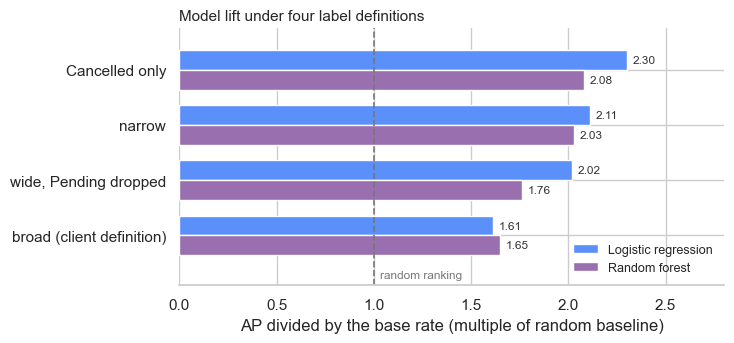

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))

labels = sensitivity["label"].unique()
positions = np.arange(len(labels))
height = 0.36

for offset, model_name in zip([height / 2, -height / 2], MODEL_COLOURS):
    subset = sensitivity[sensitivity["model"] == model_name]
    values = [subset[subset["label"] == l]["AP / base rate"].iloc[0] for l in labels]
    bars = ax.barh(positions + offset, values, height=height,
                   color=MODEL_COLOURS[model_name], label=model_name)
    for bar, value in zip(bars, values):
        ax.text(value + 0.03, bar.get_y() + bar.get_height() / 2, f"{value:.2f}",
                va="center", fontsize=8.5, color="#333333")

ax.axvline(1.0, color=REFERENCE, linestyle="--", linewidth=1.2)
ax.set_ylim(-0.9, len(labels) - 0.25)
ax.text(1.03, -0.72, "random ranking", fontsize=8.5, color=REFERENCE, va="center")
ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel("AP divided by the base rate (multiple of random baseline)")
ax.set_title("Model lift under four label definitions", loc="left", fontsize=11)
ax.set_xlim(0, 2.8)
ax.legend(frameon=False, fontsize=9, loc="lower right")
sns.despine(left=True)
fig.tight_layout()
fig.savefig("../figures/13_label_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

### Label sensitivity result

The ranking remains above the random baseline under all four definitions. AP is
about 1.6 times the baseline under the broader label and about 2.0 to 2.3
times the baseline under the narrow and `Cancelled`-only versions.

The absolute AP values fall as the labels get stricter, from 0.375 down to about
0.19, because there are fewer positives to find, and the fold-to-fold spread
grows, so the stricter numbers are less certain. This suggests that the measured
signal is not entirely produced by the `Pending` group. It still does not prove
that every `Pending` record is an actual business failure.

## 6. Hyperparameter tuning

The draft results were untuned. I search a grid for both models inside nested
cross-validation, where an inner 5-fold search picks the settings and an outer
loop scores the whole procedure on data the search never saw. Comparing an inner
search score against an untuned score would be unfair, because the inner score is
the best of many attempts on the same data.

In [6]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

SEARCHES = {
    "Logistic regression": (MODELS["Logistic regression"],
                            {"clf__C": [0.01, 0.1, 1.0, 10.0, 100.0]}),
    "Random forest": (Pipeline([
        ("pre", forest_preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300,
                                       class_weight="balanced_subsample",
                                       random_state=SEED, n_jobs=1))]),
        {"clf__max_depth": [None, 4, 8],
         "clf__min_samples_leaf": [1, 3, 5],
         "clf__max_features": ["sqrt", None]}),
}

rows = []
for name, (estimator, grid) in SEARCHES.items():
    search = GridSearchCV(estimator, grid, scoring="average_precision",
                          cv=inner_cv, n_jobs=-1)

    nested = cross_val_score(search, X, y, cv=outer_cv,
                             scoring="average_precision", n_jobs=-1)

    untuned = cross_validate(MODELS[name], X, y, cv=outer_cv,
                             scoring=["average_precision"], n_jobs=-1)

    search.fit(X, y)
    rows.append({
        "model": name,
        "untuned AP": round(np.nanmean(untuned["test_average_precision"]), 3),
        "tuned AP (nested)": round(np.nanmean(nested), 3),
        "tuned AP sd": round(np.nanstd(nested), 3),
        "inner search AP": round(search.best_score_, 3),
        "best params": str(search.best_params_).replace("clf__", ""),
    })

tuning = pd.DataFrame(rows).set_index("model")
pd.set_option("display.max_colwidth", 80)
tuning

,untuned AP,tuned AP (nested),tuned AP sd,inner search AP,best params
model,,,,,
Logistic regression,0.384,0.362,0.054,0.399,{'C': 0.01}
Random forest,0.385,0.368,0.075,0.434,"{'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1}"


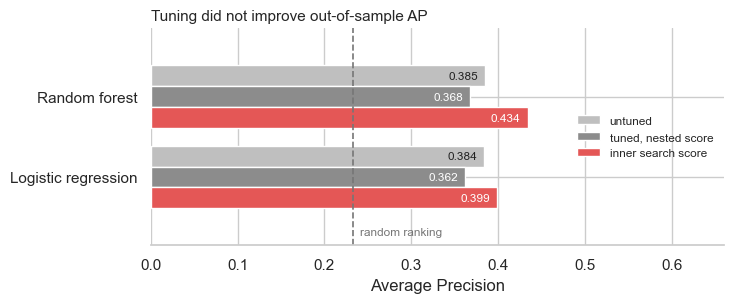

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))

names = list(tuning.index)
positions = np.arange(len(names))
height = 0.26
series = [("untuned AP", "#BFBFBF", "untuned"),
          ("tuned AP (nested)", "#8C8C8C", "tuned, nested score"),
          ("inner search AP", "#E45756", "inner search score")]

for offset, (column, colour, legend_label) in zip([height, 0, -height], series):
    values = tuning[column].values
    bars = ax.barh(positions + offset, values, height=height, color=colour,
                   label=legend_label)
    text_colour = "#222222" if colour == "#BFBFBF" else "white"
    for bar, value in zip(bars, values):
        ax.text(value - 0.008, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
                ha="right", va="center", fontsize=8.5, color=text_colour)

ax.axvline(BASE_RATE, color=REFERENCE, linestyle="--", linewidth=1.2)
ax.set_ylim(-0.85, len(names) - 0.15)
ax.text(BASE_RATE + 0.008, -0.68, "random ranking", fontsize=8.5, color=REFERENCE,
        va="center")
ax.set_yticks(positions)
ax.set_yticklabels(names)
ax.set_xlabel("Average Precision")
ax.set_title("Tuning did not improve out-of-sample AP", loc="left", fontsize=11)
ax.set_xlim(0, 0.66)
ax.legend(frameon=False, fontsize=8.5, loc="center right")
sns.despine(left=True)
fig.tight_layout()
fig.savefig("../figures/14_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

### Tuning result

Tuning did not help. On the same outer folds the untuned models scored 0.384 and
0.385, while the tuned nested scores were 0.362 and 0.368. The differences are
small compared with the fold-to-fold spread, so I found no evidence that tuning
helped.

The inner searches reported 0.399 and 0.434, but those values were used to choose
the settings and are not final performance estimates. Their higher values show why
the outer nested scores are needed. The gap reflects both model-selection optimism
and the variability of this small dataset, so I do not treat it as an exact bias
estimate.

I therefore keep the simpler untuned settings.

## 7. Stability of the status ranking at k = 10

The client confirmed a target of around 10 contacts per week. The draft measured
precision@k on one out-of-fold ranking, which was not enough to understand the
variation. Here I rebuild the ranking 25 times with different splits. Each split
ranks validation records from the full 219-record dataset, not only the issued
businesses in the final contact list.

In [8]:
def precision_at_k(y_true, scores, k):
    return y_true.iloc[np.argsort(-scores)[:k]].mean()


N_REPEATS = 25
K_GRID = np.arange(5, 81)
REPORT_KS = [10, 20, 30, 50]

curves, spread_rows = {}, []
for name, model in MODELS.items():
    per_split = []
    for repeat in range(N_REPEATS):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + repeat)
        scores = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
        per_split.append([precision_at_k(y, scores, k) for k in K_GRID])

    curves[name] = np.array(per_split)

    for k in REPORT_KS:
        values = curves[name][:, list(K_GRID).index(k)]
        spread_rows.append({
            "model": name, "k": k,
            "mean": round(values.mean(), 3), "sd": round(values.std(), 3),
            "worst split": round(values.min(), 3),
            "best split": round(values.max(), 3),
            "% of splits above base rate": round((values > BASE_RATE).mean() * 100),
        })

stability = pd.DataFrame(spread_rows)
print(f"base rate {BASE_RATE:.3f}, {N_REPEATS} repeated 5-fold rankings\n")
stability

base rate 0.233, 25 repeated 5-fold rankings



,model,k,mean,sd,worst split,best split,% of splits above base rate
0,Logistic regression,10,0.280,0.089,0.100,0.400,64
1,Logistic regression,20,0.286,0.074,0.150,0.450,80
2,Logistic regression,30,0.309,0.060,0.167,0.433,96
3,Logistic regression,50,0.314,0.036,0.260,0.380,100
4,Random forest,10,0.292,0.123,0.100,0.500,60
5,Random forest,20,0.334,0.083,0.200,0.500,92
6,Random forest,30,0.331,0.057,0.200,0.433,96
7,Random forest,50,0.305,0.034,0.220,0.380,96


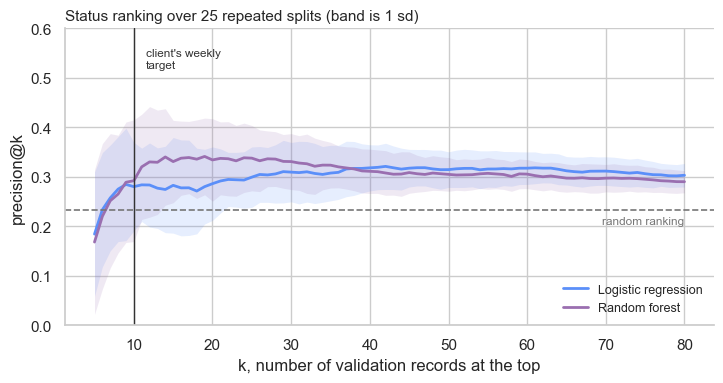

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))

for name, matrix in curves.items():
    mean_curve = matrix.mean(axis=0)
    sd_curve = matrix.std(axis=0)
    ax.plot(K_GRID, mean_curve, linewidth=2, color=MODEL_COLOURS[name], label=name)
    ax.fill_between(K_GRID, mean_curve - sd_curve, mean_curve + sd_curve,
                    color=MODEL_COLOURS[name], alpha=0.15, linewidth=0)

ax.axhline(BASE_RATE, color=REFERENCE, linestyle="--", linewidth=1.2)
ax.text(80, BASE_RATE - 0.012, "random ranking", fontsize=8.5, color=REFERENCE,
        ha="right", va="top")

ax.axvline(CONTACTS_PER_WEEK, color="#333333", linewidth=1)
ax.text(CONTACTS_PER_WEEK + 1.5, 0.52, "client's weekly\ntarget", fontsize=8.5,
        color="#333333")

ax.set_xlabel("k, number of validation records at the top")
ax.set_ylabel("precision@k")
ax.set_title(f"Status ranking over {N_REPEATS} repeated splits (band is 1 sd)",
             loc="left", fontsize=11)
ax.set_ylim(0, 0.6)
ax.legend(frameon=False, fontsize=9, loc="lower right")
sns.despine()
fig.tight_layout()
fig.savefig("../figures/15_ranking_stability.png", dpi=150, bbox_inches="tight")
plt.show()

### Precision at k result

At k = 10, logistic regression has a mean precision of 0.280 and the random forest
has 0.292, against a base rate of 0.233. The top 10 validation records therefore
contain an average of about 2.8 to 2.9 records with a failure status, compared with
2.3 under random ordering.

The spread matters more than the average. Across the 25 splits precision@10 ran
from 0.10 to 0.40 for logistic regression and from 0.10 to 0.50 for the forest,
and only **64 percent and 60 percent of splits beat the base rate**. In roughly a
third of splits the top 10 was no better than picking 10 businesses at random.

The variability falls as k grows. By k = 30, 96 percent of splits are above the
base rate for both models. The average precision does not rise much, but the spread
narrows.

This test does not show that 2.9 of 10 currently issued businesses will later
fail. It ranks records using current status labels, while the delivered list
contains only issued records and has no future outcomes. The food bank would need
to try the list and record the contact results before claiming a real hit rate.

## 8. Can the scores be read as probabilities?

The proposal asks for a score from 0 to 1 per business. The scores are in that
range, but that does not automatically make them probabilities, so I checked.

Logistic regression  mean predicted 0.451  actual rate 0.233
Random forest        mean predicted 0.402  actual rate 0.233


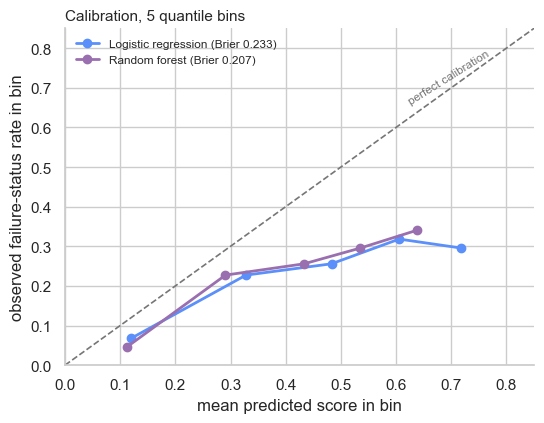

In [10]:
calibration_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_scores = {}

fig, ax = plt.subplots(figsize=(5.6, 4.4))
for name, model in MODELS.items():
    scores = cross_val_predict(model, X, y, cv=calibration_cv,
                               method="predict_proba")[:, 1]
    oof_scores[name] = scores

    observed, predicted = calibration_curve(y, scores, n_bins=5, strategy="quantile")
    ax.plot(predicted, observed, marker="o", markersize=6, linewidth=2,
            color=MODEL_COLOURS[name],
            label=f"{name} (Brier {brier_score_loss(y, scores):.3f})")

    print(f"{name:20s} mean predicted {scores.mean():.3f}  actual rate {y.mean():.3f}")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, color=REFERENCE)
ax.text(0.62, 0.66, "perfect calibration", fontsize=8.5, color=REFERENCE,
        rotation=32)

ax.set_xlabel("mean predicted score in bin")
ax.set_ylabel("observed failure-status rate in bin")
ax.set_title("Calibration, 5 quantile bins", loc="left", fontsize=11)
ax.set_xlim(0, 0.85)
ax.set_ylim(0, 0.85)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
sns.despine()
fig.tight_layout()
fig.savefig("../figures/16_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

### Calibration result

The scores are **not** probabilities. Both models sit well below the diagonal. The
average predicted score is 0.451 for logistic regression and 0.402 for the forest,
while the actual failure rate is 0.233. A business scored 0.7 does not have a 70
percent chance of being at risk.

Both models use balanced class weights, which increase the influence of the
minority class during fitting. This can help ordering while making the raw scores
too high for probability interpretation.

The observed failure-status rate generally rises across the score bins, so the
scores still provide an ordering in this dataset.

For the deliverable I therefore report the score alongside a **band and a
position**. I did not apply probability calibration because there are only 51
positive records and no later outcome period on which to validate calibrated
probabilities.

## 9. Held-out check

The Phase 2 agreement sets the validation plan: an 80/20 stratified split, with
cross-validation inside the training portion rather than tuning against the
held-out part, and cross-validation over the full dataset reported as the steadier
number. Sections 5 to 8 are the full-dataset cross-validation. This section is the
80/20 part.

The grid search runs on the training portion only, so the held-out 20 percent is
scored exactly once.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print(f"train {len(y_train)} rows ({y_train.sum()} positives), "
      f"test {len(y_test)} rows ({y_test.sum()} positives)")
print(f"test base rate {y_test.mean():.3f}\n")

rows = []
for name, model in MODELS.items():
    untuned_fit = clone(model).fit(X_train, y_train)
    untuned_scores = untuned_fit.predict_proba(X_test)[:, 1]

    estimator, grid = SEARCHES[name]
    search = GridSearchCV(clone(estimator), grid, scoring="average_precision",
                          cv=inner_cv, n_jobs=-1).fit(X_train, y_train)
    tuned_scores = search.predict_proba(X_test)[:, 1]

    rows.append({
        "model": name,
        "untuned AP": round(average_precision_score(y_test, untuned_scores), 3),
        "tuned on train, AP": round(average_precision_score(y_test, tuned_scores), 3),
        "untuned precision@10": round(precision_at_k(y_test, untuned_scores, 10), 2),
    })

held_out = pd.DataFrame(rows).set_index("model")
held_out

train 175 rows (41 positives), test 44 rows (10 positives)
test base rate 0.227



,untuned AP,"tuned on train, AP",untuned precision@10
model,,,
Logistic regression,0.562,0.689,0.5
Random forest,0.581,0.430,0.5


### Held-out result

Both models score higher on the held-out set than in cross-validation, with
untuned AP of 0.562 and 0.581 against 0.375 and 0.385 from the repeated
cross-validation.

Tuning on the training portion moved logistic regression to 0.689 and the forest
to 0.430. The opposite movements show how strongly a 44-row test set with only 10
positives can change when a few records are ranked differently.

I therefore do not treat the higher held-out values as evidence that the models
perform better than repeated cross-validation suggests. The repeated results remain
the main evaluation.

## 10. The final model

The Phase 2 agreement asks for a random forest as the handed-over model and uses
logistic regression as the baseline comparison.

The random forest is therefore the final model. I also checked whether the results
give a reason to reject that choice:

| | Logistic regression | Random forest |
|---|---|---|
| AP, repeated CV | 0.375 | 0.385 |
| precision@10, mean over 25 splits | 0.280 | 0.292 |
| precision@20 | 0.286 | 0.334 |
| precision@30 | 0.309 | 0.331 |
| held-out AP | 0.562 | 0.581 |
| tuning helped | no | no |

The forest has a slightly higher mean on every line, but the differences are
smaller than the variation across splits. The results support using the requested
forest, but they do not prove that it is reliably better than logistic regression.

Logistic regression is easier to explain, and its spread at
k = 10 is narrower (0.089 against 0.123). If the food bank later wants to explain
individual entries on the list, that model is in
[`02_Modeling.ipynb`](02_Modeling.ipynb) with its coefficients, and swapping it in
would cost little.

## 11. Contact list

The forest is fitted on all 219 labelled businesses and used to score the **168
businesses whose licence is currently `Issued`**. Businesses that already carry a
failure status are training examples, not candidates for a support call, so they
are not in the list.

Those 168 businesses were included in the training data as negatives, so their
scores are in-sample. The validation results in Sections 5 to 9 come from held-out
records within the full dataset and do not validate future outcomes for this list.
The model is also cross-sectional. A high score means that a business resembles
records that currently carry a failure status, not that it is predicted to close on
a particular date.

The top 30 is used as the high band because the repeated validation was more stable
at k = 30 than at k = 10. The next 40 are medium and the rest are low. These bands
make the list easier to use; they are not probability categories.

In [12]:
FINAL_MODEL_NAME = "Random forest"
final_model = clone(MODELS[FINAL_MODEL_NAME]).fit(X, y)

open_businesses = model_df[model_df["status"] == "Issued"].copy()
open_businesses["risk_score"] = final_model.predict_proba(
    open_businesses[FEATURES])[:, 1]

contact_list = open_businesses.sort_values("risk_score", ascending=False).copy()
contact_list["rank"] = np.arange(1, len(contact_list) + 1)
contact_list["contact_week"] = np.ceil(
    contact_list["rank"] / CONTACTS_PER_WEEK).astype(int)
contact_list["risk_band"] = np.where(
    contact_list["rank"] <= 30, "high",
    np.where(contact_list["rank"] <= 70, "medium", "low"))

print(f"model  : {FINAL_MODEL_NAME}, fitted on all {len(X)} labelled rows")
print(f"scored : {len(contact_list)} businesses with an Issued licence")
print(f"weeks  : {contact_list['contact_week'].max()} at "
      f"{CONTACTS_PER_WEEK} contacts per week")
print(contact_list["risk_band"].value_counts().reindex(
    ["high", "medium", "low"]).to_string())

model  : Random forest, fitted on all 219 labelled rows
scored : 168 businesses with an Issued licence
weeks  : 17 at 10 contacts per week
risk_band
high      30
medium    40
low       98


In [13]:
DELIVERABLE_COLUMNS = ["rank", "contact_week", "risk_band", "licencenumber",
                       "businessname", "businesstype", "localarea",
                       "numberofemployees", "risk_score"]

deliverable = contact_list[DELIVERABLE_COLUMNS].round({"risk_score": 3})

from pathlib import Path
Path("../outputs").mkdir(exist_ok=True)
deliverable.to_csv("../outputs/ranked_contact_list.csv", index=False)
print(f"wrote ../outputs/ranked_contact_list.csv with {len(deliverable)} rows\n")

print("Week 1, the first 10 businesses for the coordinator to contact:")
deliverable.head(CONTACTS_PER_WEEK).set_index("rank")

wrote ../outputs/ranked_contact_list.csv with 168 rows

Week 1, the first 10 businesses for the coordinator to contact:


,contact_week,risk_band,licencenumber,businessname,businesstype,localarea,numberofemployees,risk_score
rank,,,,,,,,
1,1,high,24-239342,BELLA GELATERIA GLOBAL INC.,Restaurant,Downtown,8.0,0.781
2,1,high,24-251784,TGI FOODS CORP.,Retail Dealer - Food,Downtown,3.0,0.771
3,1,high,24-267018,1485877 BC Ltd,Retail Dealer - Food,Downtown,4.0,0.759
4,1,high,24-130232,The Nut Merchant Ltd,Food Manufacturer Assembler and Processor,Sunset,2.0,0.715
5,1,high,24-243829,1158456 B.C. LTD.,Retail Dealer - Food,Sunset,2.0,0.703
6,1,high,24-259029,(Sharleen Khurana),Retail Dealer - Food,Sunset,1.0,0.661
7,1,high,24-243303,MUME TEA & WARE LTD.,Retail Dealer - Food,Mount Pleasant,2.0,0.621
8,1,high,24-186839,1399737 B.C. LTD.,Restaurant,Downtown,15.0,0.620
9,1,high,24-148035,Simon Fraser University,Restaurant,Downtown,10.0,0.613


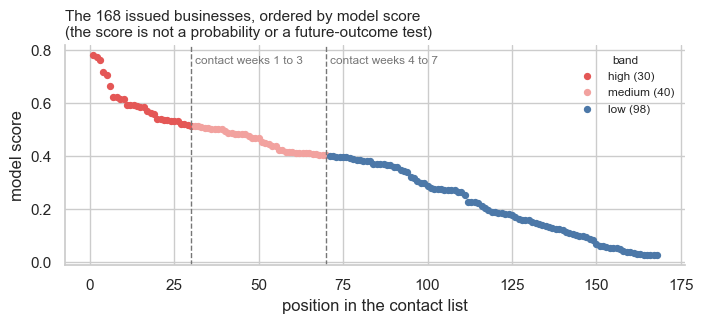

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))

band_colours = {"high": PALETTE["failed"], "medium": "#F2A29F",
                "low": PALETTE["survived"]}
for band in ["high", "medium", "low"]:
    subset = contact_list[contact_list["risk_band"] == band]
    ax.scatter(subset["rank"], subset["risk_score"], s=18,
               color=band_colours[band], label=f"{band} ({len(subset)})")

for boundary in [30, 70]:
    ax.axvline(boundary, color=REFERENCE, linestyle="--", linewidth=1)
ax.text(31, contact_list["risk_score"].max(), "contact weeks 1 to 3", fontsize=8.5,
        color=REFERENCE, va="top")
ax.text(71, contact_list["risk_score"].max(), "contact weeks 4 to 7", fontsize=8.5,
        color=REFERENCE, va="top")

ax.set_xlabel("position in the contact list")
ax.set_ylabel("model score")
ax.set_title("The 168 issued businesses, ordered by model score\n"
             "(the score is not a probability or a future-outcome test)",
             loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, title="band", title_fontsize=8.5)
sns.despine()
fig.tight_layout()
fig.savefig("../figures/17_contact_list.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
profile = (contact_list.head(30)
           .groupby("businesstype")
           .agg(in_top_30=("rank", "size"))
           .join(model_df.groupby("businesstype")
                 .agg(all_businesses=("status", "size"),
                      failure_rate=("failed_wide", "mean")))
           .sort_values("in_top_30", ascending=False)
           .round({"failure_rate": 3}))
profile

,in_top_30,all_businesses,failure_rate
businesstype,,,
Restaurant,13,74,0.284
Limited Service Food Establishment,6,41,0.244
Retail Dealer - Food,6,23,0.435
Food Manufacturer Assembler and Processor,5,17,0.412


### Profile of the top 30

The top 30 leans toward the types with high observed failure rates. Retail dealers
are 10 percent of the businesses but 20 percent of the top 30, and food
manufacturers are 8 percent of the businesses but 17 percent of the top 30. Both
have observed failure rates above 0.40. Wholesale dealers, the type with the
lowest failure rate in the EDA at 4.8 percent, do not appear in the top 30 at all.
Restaurants supply the most rows simply because they are the largest category.

That is the model behaving the way the EDA would predict, which is a sanity check
rather than evidence that the list is right.

It also shows the main weakness of the deliverable. With three predictors the
model is close to sorting businesses by category, so two restaurants in the same
neighbourhood with similar staff counts get almost the same score. The list is
best read as "start with these kinds of business in these areas" rather than as a
precise ordering of individual businesses.

## 12. Does this meet the success criteria?

The proposal gives three success criteria.

| Criterion | Result | Evidence |
|---|---|---|
| Perform better than random at ranking failure-status records | Met for this dataset | The forest's AP is 0.385, or 1.65 times the random baseline of 0.233. It remains above the baseline under all four label definitions |
| Compare business type and staff count as early signs | Partly met | Cross-validated permutation importance has means of 0.062 for business type, 0.018 for employees, and -0.006 for neighbourhood. Business type has the largest mean, but all estimates vary across folds and the other two are close to zero |
| Provide an actionable cutoff | Met for the contact schedule | The client confirmed around 10 contacts per week, so the CSV is batched in groups of 10. The cutoff has not been tested on future outcomes |

The first client question asks whether licence data contains a failure pattern. The
models find a weak pattern in current status labels, and the measured lift remains
above the random baseline under stricter label definitions.

For the second question, business type has more evidence than employee count in
this dataset, but the importance estimates are not stable enough for a confident
ranking of all three predictors.

For the third question, the model can produce the requested contact list. The
analysis does not show that the highest-ranked issued businesses are the ones that
will fail later, because the dataset has no later outcome period. The list should
therefore be presented as a list to try out, not as a validated forecast.

## 13. Limitations and what I would do differently

The cleaned dataset contains 219 records and 51 positives under the broad
label Jason confirmed. The validation results change noticeably across splits. The
client confirmed how `Pending` and `Inactive` should be treated for this project,
but the dataset does not prove that every such record represents a
failed business.

Only business type, neighbourhood, and employee count are used. The model cannot
see rent, revenue, debt, ownership changes, business age, or previous food-bank
support. The raw scores are not probabilities. The rare-category thresholds were
chosen from the full dataset during EDA, which makes the cross-validation slightly
optimistic.

The largest limitation is that the dataset is a snapshot rather than a timeline.
The evaluation ranks records with known current statuses, while the delivered list
contains only currently issued businesses. Those issued records were included as
training negatives, so their final scores are in-sample. There is no later outcome
showing which of them eventually failed.

With more time and better data, I would:

- obtain licence records from multiple years and define the outcome as open in one
  period and closed in a later period;
- keep the most recent period as a later test set;
- add business age and any support history the food bank can provide; and
- record the outcomes of the first contacts before choosing a permanent cutoff or
  treating the score as a real measure of failure risk.

## 14. Executive summary

The deliverable is a ranked list of 168 Vancouver food businesses whose current
licence status is `Issued`. The random forest orders them by how closely they
resemble records that have a failure status in this dataset. The CSV is grouped in
sets of 10 using the approximate weekly capacity confirmed by the client.

In repeated cross-validation, the forest reached an AP of 0.385 compared with a
random baseline of 0.233. At k = 10, the top 10 validation records contained an
average of 2.9 records already marked with a failure status, compared with 2.3
under random ordering. The result varied considerably across splits.

This evaluation did not follow currently issued businesses into the future, so it
does not mean that about 3 of every 10 contacted businesses will later close. The
issued businesses were also included as negatives when the final model was fitted.
The contact list should therefore be tried as a contact list, not treated as a
validated forecast.

The `risk_score` orders businesses but is not a probability. A score of 0.70 does
not mean a 70 percent chance of closure. The model only uses business type,
neighbourhood, and employee count, so similar businesses can receive nearly the
same score.

The client confirmed the broad failure definition and a target of around 10
contacts per week. The most useful modelling improvement would still be multi-year licence records,
which would let me test the model using outcomes from a later year.

## 15. Links

- **Repository:** https://github.com/Mhd-tz/Predicting-Failed-Food-Businesses
- **Recorded presentation:** https://vault.sfu.ca/index.php/s/dHyXreFSdrXPcir
- **Streamlit app:** https://predicting-failed-food-businesses-a2pmx3bnzwcbxi87r8jtds.streamlit.app/
- **Deliverable:** [`outputs/ranked_contact_list.csv`](../outputs/ranked_contact_list.csv)
- **Earlier notebooks:** [`01_EDA.ipynb`](01_EDA.ipynb),
  [`02_Modeling.ipynb`](02_Modeling.ipynb)